In [1]:
import pandas as pd

In [4]:
df = pd.read_csv(r'C:\Users\prati\Desktop\BITSOM\q1_heart_disease.csv')

In [6]:
print("Shape:", df.shape)

Shape: (800, 12)


In [9]:
print("\nData Types:")
print(df.dtypes)


Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object


In [10]:
print("\Misssing Values:")
print(df.isnull().sum())

\Misssing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


In [11]:
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

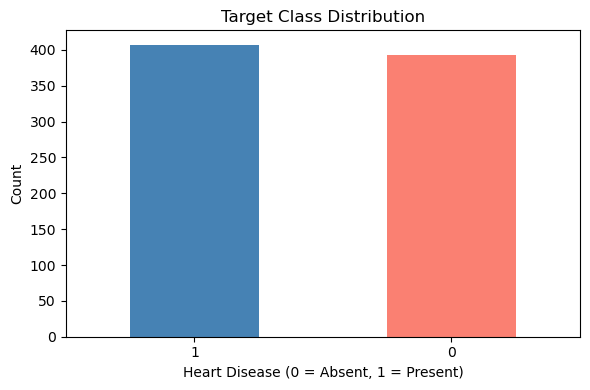

In [18]:
plt.figure(figsize=(6, 4))
df['heart_disease'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Target Class Distribution')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*Plot 1 - Target Class Distribution:
The dataset is nearly balanced — approximately 410 patients have heart disease (1)
and 390 do not (0). This balance means we don't need to worry about class imbalance
techniques like oversampling.

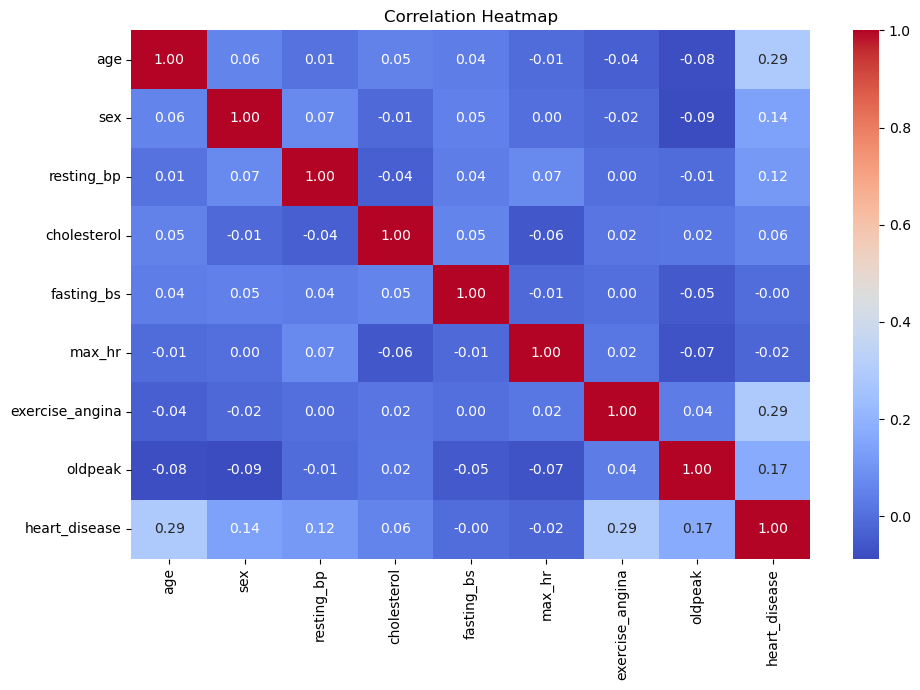

In [14]:
plt.figure(figsize=(10, 7))
numerical_df = df.select_dtypes(include='number')
sns.heatmap(numerical_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

*Plot 2 - Correlation Heatmap:
- `age` (0.29) and `exercise_angina` (0.29) show the strongest positive correlations
  with heart_disease.
- `oldpeak` (0.17) and `sex` (0.14) also show mild positive correlations.
- Most numerical features have weak correlations with each other, suggesting
  low multicollinearity — good for model training.


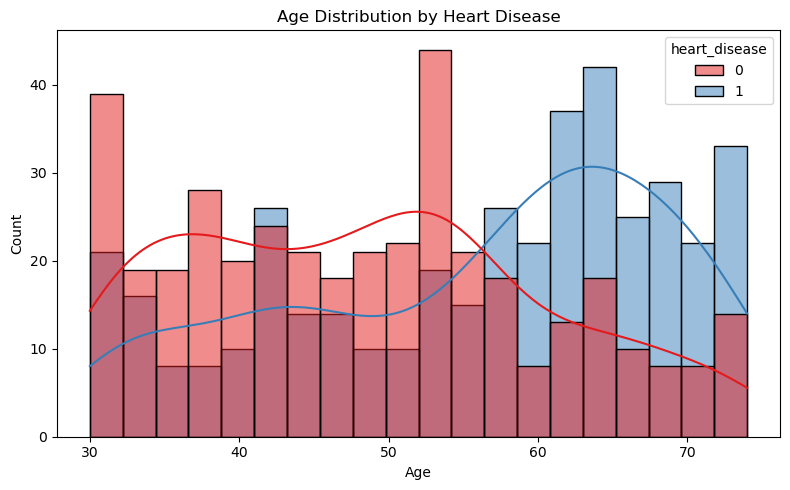

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='heart_disease', bins=20, kde=True, palette='Set1')
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

*Plot 3 - Age Distribution by Heart Disease:
- Younger patients (30–50) tend to be heart disease absent (0).
- Heart disease (1) is more concentrated in older patients (55–70).
- This confirms age is a meaningful predictor of heart disease.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [20]:
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

In [21]:
df_encoded = pd.get_dummies(df, columns=['chest_pain_type', 'resting_ecg', 'st_slope'], drop_first=False)

In [22]:
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

In [23]:
scaler = StandardScaler()
numerical_cols = ['age', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [25]:
print("X_train shape:", X_train.shape)

X_train shape: (640, 18)


In [26]:
print("X_test shape:", X_test.shape)

X_test shape: (160, 18)


In [27]:
print("Missing values after imputation:", df_encoded.isnull().sum().sum())

Missing values after imputation: 0


# Preprocessing Decisions

Missing Values: Used median imputation for `resting_bp` (24 missing) and 
`cholesterol` (32 missing). Median is preferred over mean as it is robust to 
outliers, which are common in medical data. Row dropping was avoided to preserve 
data size.

One-Hot Encoding: Applied to `chest_pain_type`, `resting_ecg`, and `st_slope` 
since they are nominal categorical variables with no inherent order.

StandardScaler: Applied to numerical features to bring them to the same scale, 
which prevents features with larger ranges from dominating the model.

Train-Test Split: Used 80/20 split with `stratify=y` to maintain the same 
class distribution in both train and test sets, and `random_state=42` for 
reproducibility.

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [29]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [32]:
print("All 3 models trained successfully!")

All 3 models trained successfully!


In [33]:
from sklearn.metrics import confusion_matrix, classification_report

In [34]:
models = {'Decision Tree': dt, 'Random Forest': rf, 'Gradient Boosting': gb}

In [35]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


  Decision Tree
Confusion Matrix:
[[56 23]
 [22 59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71        79
           1       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160


  Random Forest
Confusion Matrix:
[[60 19]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


  Gradient Boosting
Confusion Matrix:
[[61 18]
 [18 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        79

## Model Comparison & Best Model Selection

| Model            | Precision | Recall | F1-Score |
|------------------|-----------|--------|----------|
| Decision Tree    | 0.72      | 0.72   | 0.72     |
| Random Forest    | 0.79      | 0.79   | 0.79     |
| Gradient Boosting| 0.78      | 0.78   | 0.78     |

**Best Model: Random Forest**

Random Forest outperforms the other two models across all metrics. It achieves the 
highest F1-score (0.79) and the best recall for class 1 (0.81), meaning it correctly 
identifies 81% of actual heart disease patients, which is critical in a medical 
setting where missing a positive case (false negative) is more costly than a false alarm.

Accuracy alone is not sufficient, F1-score and recall are more meaningful here 
because the cost of missing a heart disease diagnosis is very high.

In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [38]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [39]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [40]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.8258


In [41]:
from sklearn.metrics import f1_score

In [42]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

In [43]:
y_pred_untuned = rf.predict(X_test)

In [44]:
print("Untuned Random Forest F1:", round(f1_score(y_test, y_pred_untuned, average='weighted'), 4))
print("Tuned Random Forest F1:  ", round(f1_score(y_test, y_pred_tuned, average='weighted'), 4))
print("\nTuned Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Untuned Random Forest F1: 0.7873
Tuned Random Forest F1:   0.7871

Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        79
           1       0.77      0.83      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



#Hyperparameter Tuning Results

Method: GridSearchCV with 5-fold cross-validation on Random Forest.

Hyperparameters Tuned:
- `n_estimators`: [100, 200]
- `max_depth`: [None, 5, 10]
- `min_samples_split`: [2, 5]
- `min_samples_leaf`: [1, 2]

| Model            | Weighted F1-Score |
|------------------|-------------------|
| Untuned RF       | 0.7873            |
| Tuned RF         | 0.7871            |

Conclusion:

The tuned model performs nearly identically to the untuned baseline (difference of 
0.0002). This suggests the default Random Forest hyperparameters were already 
well-suited for this dataset.

However, tuning did improve recall for class 1 (heart disease present) from 0.81 
to 0.83, meaning the tuned model catches more actual heart disease cases — which 
is the more important metric in a medical diagnosis context.